In [19]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery
from diff_equations import grad, cooling_law
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


# Parameters

In [20]:
number_of_points = 100
noise_coeff = 5

pinn_collocation_points = 1000
parameter_discovery_collocation_points = 1000

vanilla_loss= 1
pinn_loss_weight = 1
parameter_discovery_loss__weight = 1

vanila_epochs = 20000
pinn_epochs = 20000
parameter_discovery_epochs = 20000

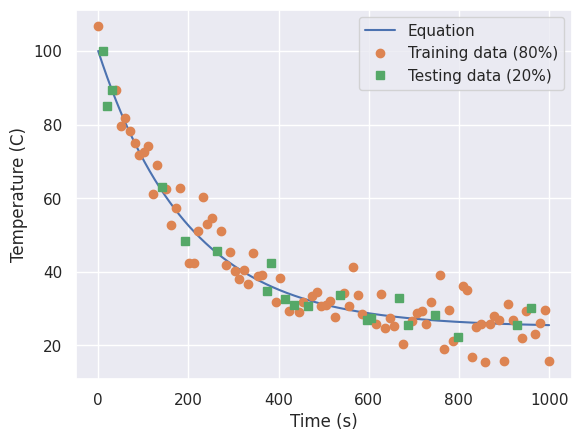

In [ ]:
np.random.seed(10)

Tenv = 25
T0 = 100
R = 0.005


times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 1000, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

x_train, x_test, y_train, y_test = train_test_split(t, T, test_size=0.2, random_state=10)

plt.plot(times, temps)
plt.plot(x_train, y_train, 'o') 
plt.plot(x_test, y_test, 's')   
plt.legend(['Equation', 'Training data (80%)', 'Testing data (20%)'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.savefig('1.png', dpi=300, bbox_inches='tight')
plt.show()

# Vanilla Networks

Loss1: <function <lambda> at 0x7f8b6faaa170>
Loss2: None
Epoch 0/20000, loss: 2291.07
Epoch 2000/20000, loss: 1194.82
Epoch 4000/20000, loss: 902.97
Epoch 6000/20000, loss: 312.88
Epoch 8000/20000, loss: 93.54
Epoch 10000/20000, loss: 48.44
Epoch 12000/20000, loss: 31.67
Epoch 14000/20000, loss: 26.84
Epoch 16000/20000, loss: 26.07
Epoch 18000/20000, loss: 25.91


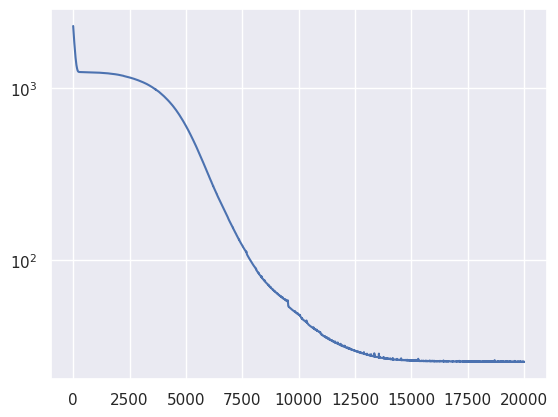

In [22]:
net = Net(1, 1, loss1=lambda model: vanilla_loss, epochs=vanila_epochs, lr=1e-5).to(DEVICE)

losses = net.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')

Mean Squared Error: 25.7787


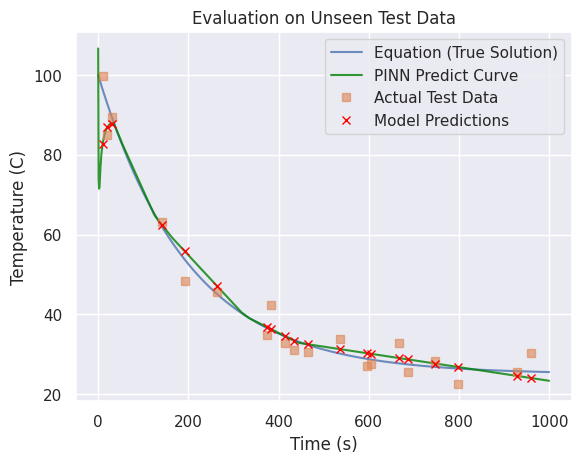

In [ ]:
# Predict specifically for the test points to calculate MSE
T_pred = net.predict(x_test)
test_mse = np.mean((T_pred.flatten() - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = net.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.savefig('2.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
def l2_reg(model: torch.nn.Module):
    return torch.sum(sum([p.pow(2.) for p in model.parameters()]))

Loss1: None
Loss2: <function l2_reg at 0x7f8b6fbb3eb0>
Epoch 0/20000, loss: 2754.25
Epoch 2000/20000, loss: 1828.47
Epoch 4000/20000, loss: 1442.10
Epoch 6000/20000, loss: 806.81
Epoch 8000/20000, loss: 614.45
Epoch 10000/20000, loss: 563.87
Epoch 12000/20000, loss: 534.80
Epoch 14000/20000, loss: 509.83
Epoch 16000/20000, loss: 486.99
Epoch 18000/20000, loss: 465.59


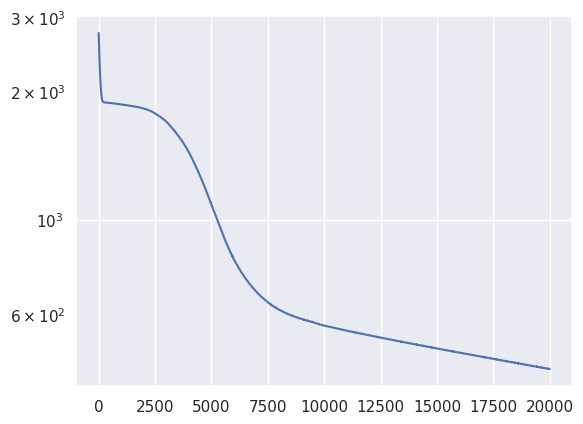

In [25]:
netreg = Net(1,1, loss2=l2_reg, epochs=vanila_epochs, lr=1e-5).to(DEVICE)

losses = netreg.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')

Mean Squared Error: 29.2180


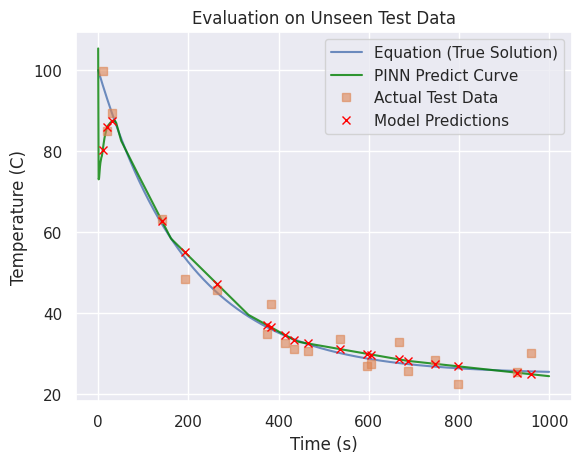

In [ ]:
# Predict specifically for the test points to calculate MSE
T_pred = netreg.predict(x_test)
test_mse = np.mean((T_pred.flatten() - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = netreg.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.savefig('3.png', dpi=300, bbox_inches='tight')
plt.show()

# Regression

In [27]:
X_train_ml = x_train.reshape(-1, 1)
X_test_ml = x_test.reshape(-1, 1)

ml_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
ml_model.fit(X_train_ml, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


Mean Squared Error: 15.3012


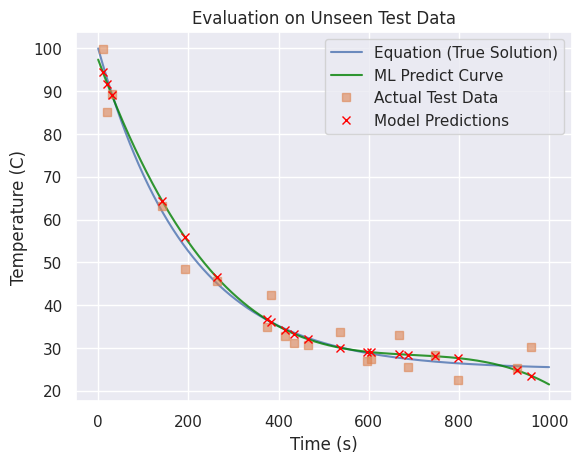

In [ ]:
# Ensure inputs are 2D for scikit-learn
X_test_ml = x_test.reshape(-1, 1)
X_times_ml = times.reshape(-1, 1)

# Predict specifically for the test points to calculate MSE
T_pred = ml_model.predict(X_test_ml)
test_mse = np.mean((T_pred - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = ml_model.predict(X_times_ml)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='ML Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.savefig('4.png', dpi=300, bbox_inches='tight')
plt.show()

# PINN

In [29]:
def physics_loss(model: torch.nn.Module, n_points=pinn_collocation_points):
    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

Loss1: None
Loss2: <function physics_loss at 0x7f8b6e0f89d0>
Epoch 0/20000, loss: 2452.54
Epoch 2000/20000, loss: 1208.78
Epoch 4000/20000, loss: 973.11
Epoch 6000/20000, loss: 367.66
Epoch 8000/20000, loss: 95.68
Epoch 10000/20000, loss: 42.98
Epoch 12000/20000, loss: 30.10
Epoch 14000/20000, loss: 26.14
Epoch 16000/20000, loss: 25.15
Epoch 18000/20000, loss: 25.02


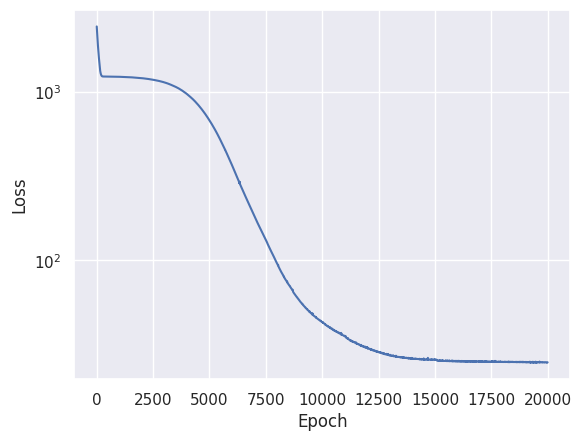

In [30]:
net = Net(1, 1, loss2=physics_loss, epochs=pinn_epochs, loss2_weight=pinn_loss_weight, lr=1e-5).to(DEVICE)

losses = net.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Text(0.5, 0, 'Time (s)')

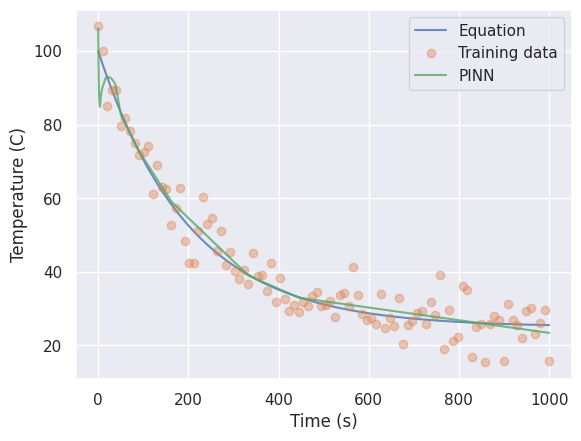

In [31]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o',alpha=0.4)
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Mean Squared Error: 18.7778


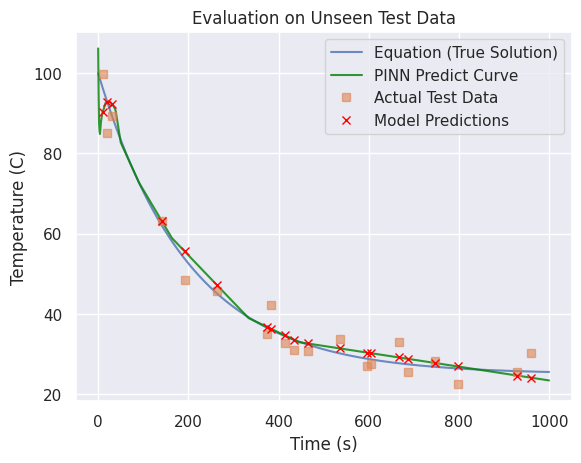

In [ ]:
# Predict specifically for the test points to calculate MSE
T_pred = net.predict(x_test)
test_mse = np.mean((T_pred.flatten() - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = net.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.savefig('5.png', dpi=300, bbox_inches='tight')
plt.show()

# Parameter discovery

In [33]:
def physics_loss_discovery(model: torch.nn.Module, n_points=parameter_discovery_collocation_points):

    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)

    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = model.r * (Tenv - temps) - dT

    return torch.mean(pde**2)

Loss1: None
Loss2: <function physics_loss_discovery at 0x7f8b6fd63880>
Epoch 0/20000, loss: 2525.59
Epoch 2000/20000, loss: 1203.14
Epoch 4000/20000, loss: 745.62
Epoch 6000/20000, loss: 141.45
Epoch 8000/20000, loss: 35.23
Epoch 10000/20000, loss: 27.72
Epoch 12000/20000, loss: 25.60
Epoch 14000/20000, loss: 25.24
Epoch 16000/20000, loss: 24.81
Epoch 18000/20000, loss: 24.58


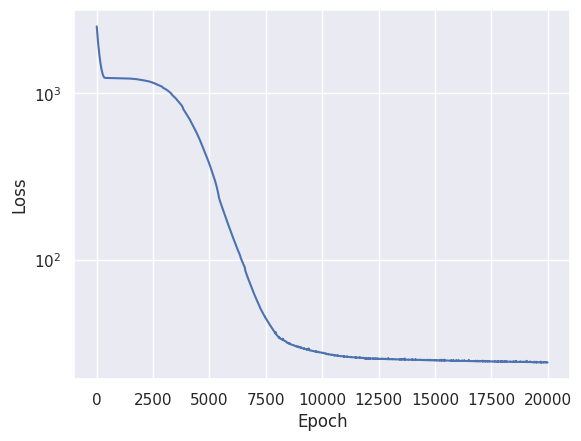

In [34]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=parameter_discovery_loss__weight, epochs=parameter_discovery_epochs, lr=1e-5).to(DEVICE)

losses = netdisc.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Parameter containing:
tensor([0.0056], device='cuda:0', requires_grad=True)


Text(0.5, 0, 'Time (s)')

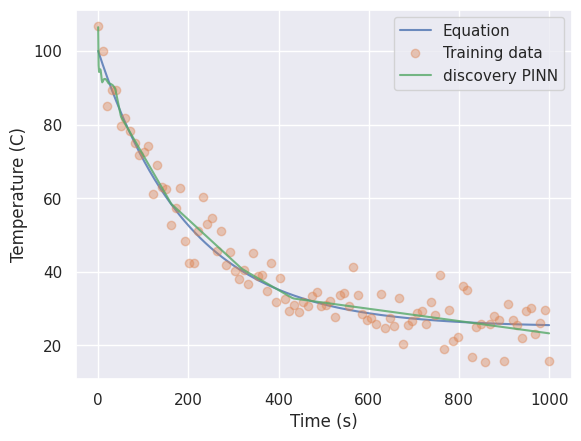

In [35]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o', alpha=0.4)
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Mean Squared Error: 15.7415
Discovered Cooling Rate (R): 0.005574
True Cooling Rate (R): 0.005


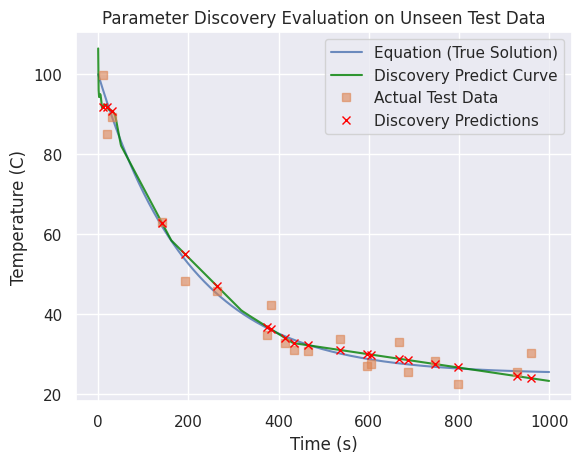

In [ ]:
# Predict specifically for the test points to calculate MSE
T_pred_disc = netdisc.predict(x_test)

test_mse_disc = np.mean((T_pred_disc.flatten() - y_test)**2)
discovered_r = netdisc.r.item()
true_r = 0.005

print(f"Mean Squared Error: {test_mse_disc:.4f}")
print(f"Discovered Cooling Rate (R): {discovered_r:.6f}")
print(f"True Cooling Rate (R): {true_r}")

# Predict across the entire continuous time domain
continuous_preds_disc = netdisc.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds_disc, label='Discovery Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred_disc, 'x', label='Discovery Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Parameter Discovery Evaluation on Unseen Test Data')
plt.savefig('6.png', dpi=300, bbox_inches='tight')
plt.show()